# Ser madre cambia el cerebro. Y se puede imitar sin tener crías.

> 8 de 13 vírgenes nunca recogen una cría. Silenciando dopamina en su hipocampo dorsal, 14 de 15 lo hacen — en menos de dos minutos.

**Paper:** [Dopamine drives persistent remodelling of the maternal brain](https://doi.org/10.1038/s41586-026-10509-4)
*Nature, 2026 · validado en 34 + 51 ratones C57BL/6J*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-20-dopamina-cerebro-maternal/notebook.ipynb)

## El acertijo

Durante el embarazo y el postparto, el cerebro materno cambia para siempre — pero ¿cómo? Para responderlo, el paper combina tres herramientas: secuenciación de ARN célula a célula, un paradigma de estrés (separar a la madre de sus crías 4 horas al día durante dos semanas) y manipulación química directa de la dopamina. Veamos los datos conductuales que sostienen esa historia.

El blanco anatómico es el **hipocampo dorsal** (dHF, *dorsal hippocampal formation*) — la región que codifica memoria contextual: dónde pasó algo, cuándo, con quién. Los datos que cargamos aquí vienen de dos experimentos conductuales del Supplementary del paper (Fig 2 y Fig 4).

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_NP = '#BBBBBB'          # Virgen sin cría (contexto basal)
COLOR_CTRL = '#2563EB'        # Madre con cría sana (azul CaM)
COLOR_STRESS = '#DC2626'      # Madre con estrés crónico (rojo alerta)
COLOR_CHEMO = '#7C3AED'       # Manipulación química DA (violeta)
CUTOFF_LATENCIA = 900         # Segundos antes de detener la observación (censura)
FUENTE_FIG2 = 'Fuente: Pearson-Fuhrhop et al. (2026), Nature | Datos: SI Fig 2'
FUENTE_FIG4 = 'Fuente: Pearson-Fuhrhop et al. (2026), Nature | Datos: SI Fig 4'

# Imports
import os, urllib.request, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local, fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos
df_fig2 = pd.read_csv('datos/fig2_estres_recall.csv')
df_fig4 = pd.read_csv('datos/fig4_pup_pickup.csv')

print(f'Fig 2 (aprendizaje contextual): {len(df_fig2)} ratones')
print(f'  grupos: {df_fig2["grupo"].unique().tolist()}')
print(f'Fig 4 (pup retrieval): {len(df_fig4)} ratones')
print(f'  grupos×virus: {df_fig4.groupby(["grupo","virus"]).size().to_dict()}')

Fig 2 (aprendizaje contextual): 34 ratones
  grupos: ['Control RE', 'Stress RE', 'NP']
Fig 4 (pup retrieval): 51 ratones
  grupos×virus: {('Control RE', 'hM4Di'): 11, ('Control RE', 'mCherry'): 12, ('NP', 'hM4Di'): 15, ('NP', 'mCherry'): 13}


## Acto 1 — Ser madre potencia el aprendizaje contextual

Aquí está.

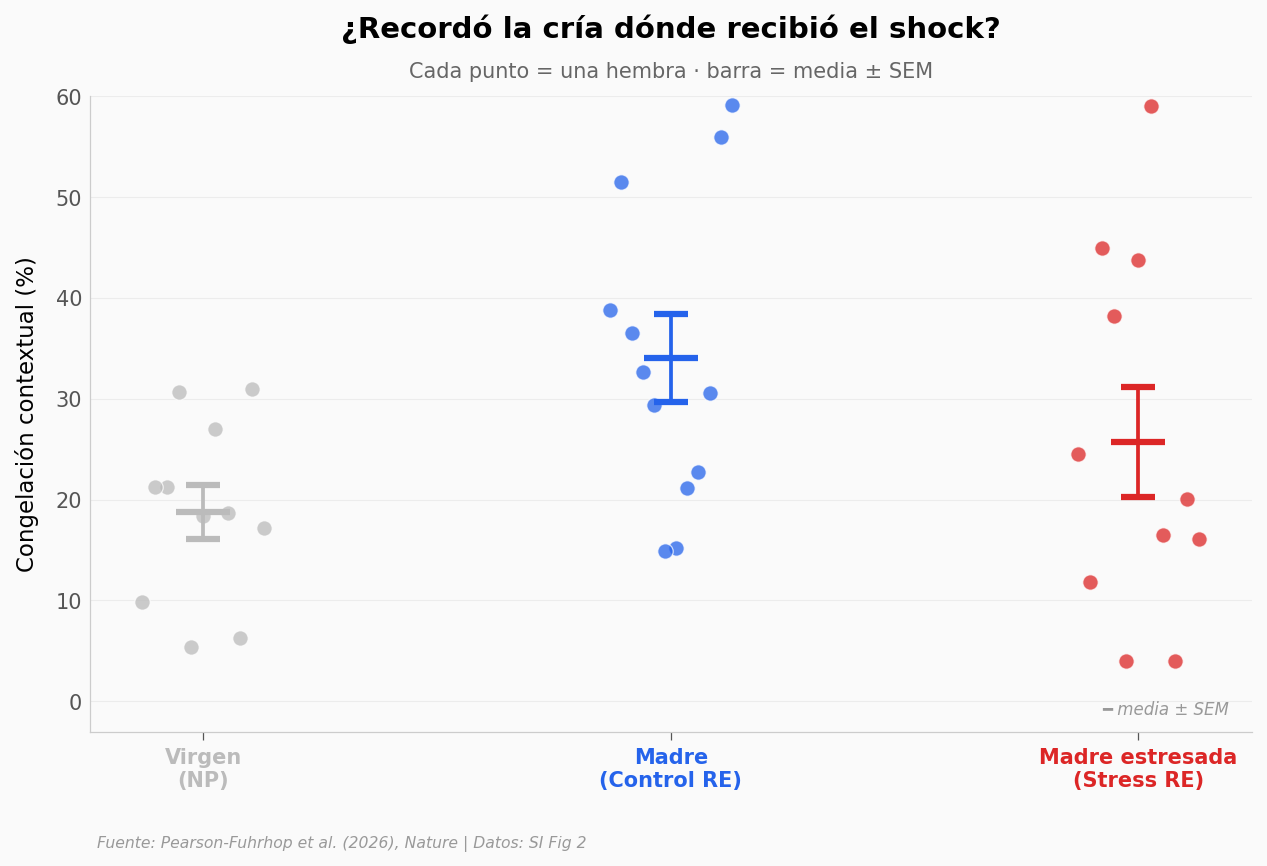

In [2]:
# Aprendizaje contextual: % de tiempo congelado al volver al contexto donde recibieron shock.
# Cada punto = una hembra. Línea ancha = media. Barras = SEM (error estándar de la media).

grupos = ['NP', 'Control RE', 'Stress RE']
labels = ['Virgen\n(NP)', 'Madre\n(Control RE)', 'Madre estresada\n(Stress RE)']
colores = [COLOR_NP, COLOR_CTRL, COLOR_STRESS]
positions = [0, 1, 2]

fig, ax = plt.subplots(figsize=(10, 5.5))

np.random.seed(42)
for pos, g, col in zip(positions, grupos, colores):
    vals = df_fig2.loc[df_fig2['grupo']==g, 'context_test_freezing'].values
    n = len(vals)
    x = np.linspace(pos - 0.13, pos + 0.13, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=col, s=55, alpha=0.75,
               edgecolors='white', linewidths=0.6, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=col,
                markersize=26, markeredgewidth=3,
                capsize=8, capthick=1.6, zorder=6)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
for tick, c in zip(ax.get_xticklabels(), colores):
    tick.set_color(c)

ax.set_ylabel('Congelación contextual (%)', fontsize=11)
ax.set_title('¿Recordó la cría dónde recibió el shock?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto = una hembra · barra = media ± SEM',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(-3, 60)

# Nota explicativa de error bars
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE_FIG2, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_aprendizaje_contextual.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** la madre control casi duplica el aprendizaje de la virgen — 34% vs 19% de tiempo congelado. La separación es grande y limpia (Cohen *d* = 1,22, Mann-Whitney U bilateral, *p* = 0,021).

**El grupo del medio guarda la pista mecanicista:** las madres estresadas crónicamente — separadas de sus crías 4 horas al día durante dos semanas — caen a una mediana de 20%, casi al nivel virgen. Pero hay alta varianza: algunas madres estresadas siguen aprendiendo bien. Ese ruido es información, no error — sugiere que la vulnerabilidad al estrés es individual.

## Acto 2 — ¿Y si silenciamos la dopamina en una virgen?

Aquí viene lo audaz. El equipo inyectó en el área ventral tegmental (VTA, fuente principal de dopamina del cerebro) un virus que expresa **hM4Di** — un receptor sintético que funciona como un interruptor químico: al darle clozapina-N-óxido, apaga selectivamente la liberación de dopamina en el dHF.

La pregunta: ¿una virgen con dopamina silenciada se comporta como una madre frente a una cría que necesita rescate?

La prueba: dejas la cría fuera del nido. Mides cuántos segundos tarda la hembra en recogerla. Cutoff a 900 segundos (15 minutos) — si no la recoge, queda censurada.

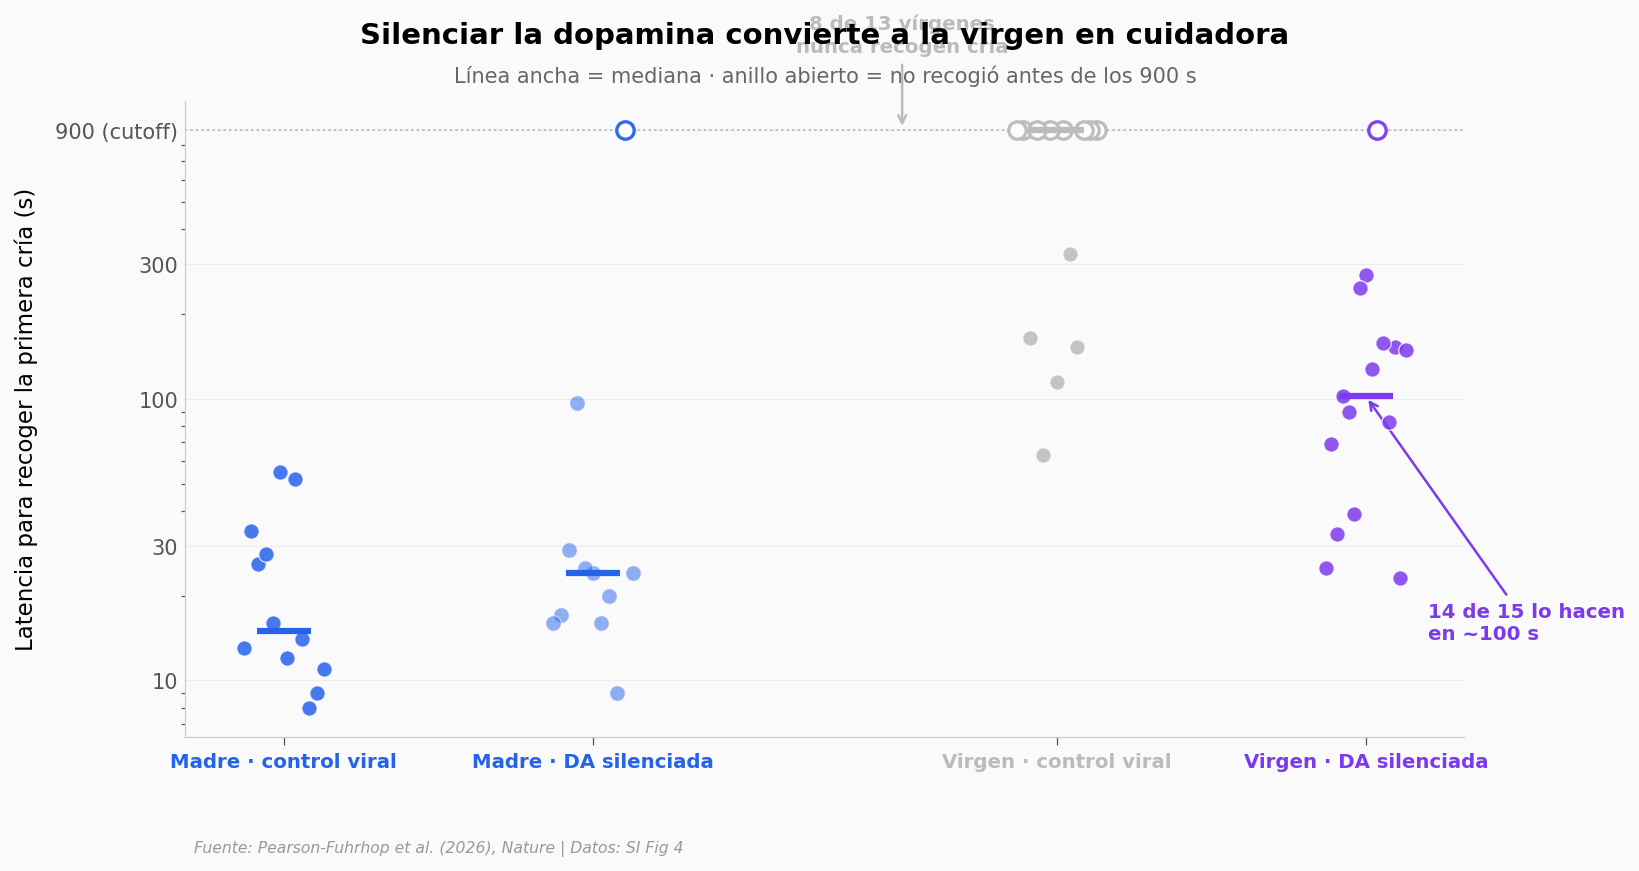

In [3]:
# Latencia de la primera cría (pup1) por grupo × virus.
# Escala log10 porque el rango va de 8s a 900s.

combos = [
    ('Control RE', 'mCherry', 'Madre · control viral'),
    ('Control RE', 'hM4Di',   'Madre · DA silenciada'),
    ('NP',         'mCherry', 'Virgen · control viral'),
    ('NP',         'hM4Di',   'Virgen · DA silenciada'),
]
colores4 = [COLOR_CTRL, COLOR_CTRL, COLOR_NP, COLOR_CHEMO]
alphas   = [0.85, 0.50, 0.85, 0.85]
positions4 = [0, 1, 2.5, 3.5]

fig, ax = plt.subplots(figsize=(11, 5.5))

np.random.seed(7)
for pos, (g, v, _), col, alpha in zip(positions4, combos, colores4, alphas):
    vals = df_fig4.loc[(df_fig4['grupo']==g) & (df_fig4['virus']==v), 'pup1_latencia_s'].values
    n = len(vals)
    cens = int((vals == CUTOFF_LATENCIA).sum())
    x = np.linspace(pos - 0.13, pos + 0.13, n)
    np.random.shuffle(x)

    # Puntos no censurados
    no_cens = vals < CUTOFF_LATENCIA
    ax.scatter(x[no_cens], vals[no_cens], color=col, s=55, alpha=alpha,
               edgecolors='white', linewidths=0.6, zorder=5)
    # Puntos censurados (anillo abierto)
    if cens > 0:
        ax.scatter(x[~no_cens], vals[~no_cens], facecolors='white', edgecolors=col,
                   s=70, linewidths=1.6, alpha=0.95, zorder=5)

    med = np.median(vals)
    ax.errorbar(pos, med, fmt='_', color=col,
                markersize=26, markeredgewidth=3, zorder=6)

ax.set_yscale('log')
ax.set_yticks([10, 30, 100, 300, 900])
ax.set_yticklabels(['10', '30', '100', '300', '900 (cutoff)'])
ax.set_ylabel('Latencia para recoger la primera cría (s)', fontsize=11)
ax.axhline(y=CUTOFF_LATENCIA, color='#999999', linewidth=1, linestyle=':', alpha=0.6)

ax.set_xticks(positions4)
ax.set_xticklabels([c[2] for c in combos], fontsize=9.5, fontweight='bold')
for tick, c in zip(ax.get_xticklabels(), colores4):
    tick.set_color(c)

ax.set_title('Silenciar la dopamina convierte a la virgen en cuidadora',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Línea ancha = mediana · anillo abierto = no recogió antes de los 900 s',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotación del rescate
ax.annotate('8 de 13 vírgenes\nnunca recogen cría',
            xy=(2.0, 900), xytext=(2.0, 1700),
            fontsize=9.5, color=COLOR_NP, ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_NP, lw=1.2))
ax.annotate('14 de 15 lo hacen\nen ~100 s',
            xy=(3.5, 102), xytext=(3.7, 14),
            fontsize=9.5, color=COLOR_CHEMO, ha='left', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_CHEMO, lw=1.2))

fig.text(0.13, -0.03, FUENTE_FIG4, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_pup_retrieval.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo crítico de la comparación:** mira las dos barras de la derecha. La virgen con control viral (gris) tiene una mediana clavada en el cutoff — más de la mitad nunca recoge cría. La virgen con dopamina silenciada (violeta) baja a 102 segundos.

El efecto es enorme: Δ mediana = -798 s, Cohen *d* = -1,50, Mann-Whitney U bilateral *p* = 0,0018 (n = 15 hM4Di vs 13 mCherry).

Las dos barras de la izquierda son el control de especificidad: en la madre, silenciar dopamina **no** cambia su comportamiento (15 s vs 24 s — ambas rápidas). Eso es lo que esperas si el sistema dopamina-dHF ya está remodelado en la madre — no queda nada que silenciar.

                 combo  n  rescatan        pct
 Madre · control viral 12        12 100.000000
 Madre · DA silenciada 11        10  90.909091
Virgen · control viral 13         5  38.461538
Virgen · DA silenciada 15        14  93.333333


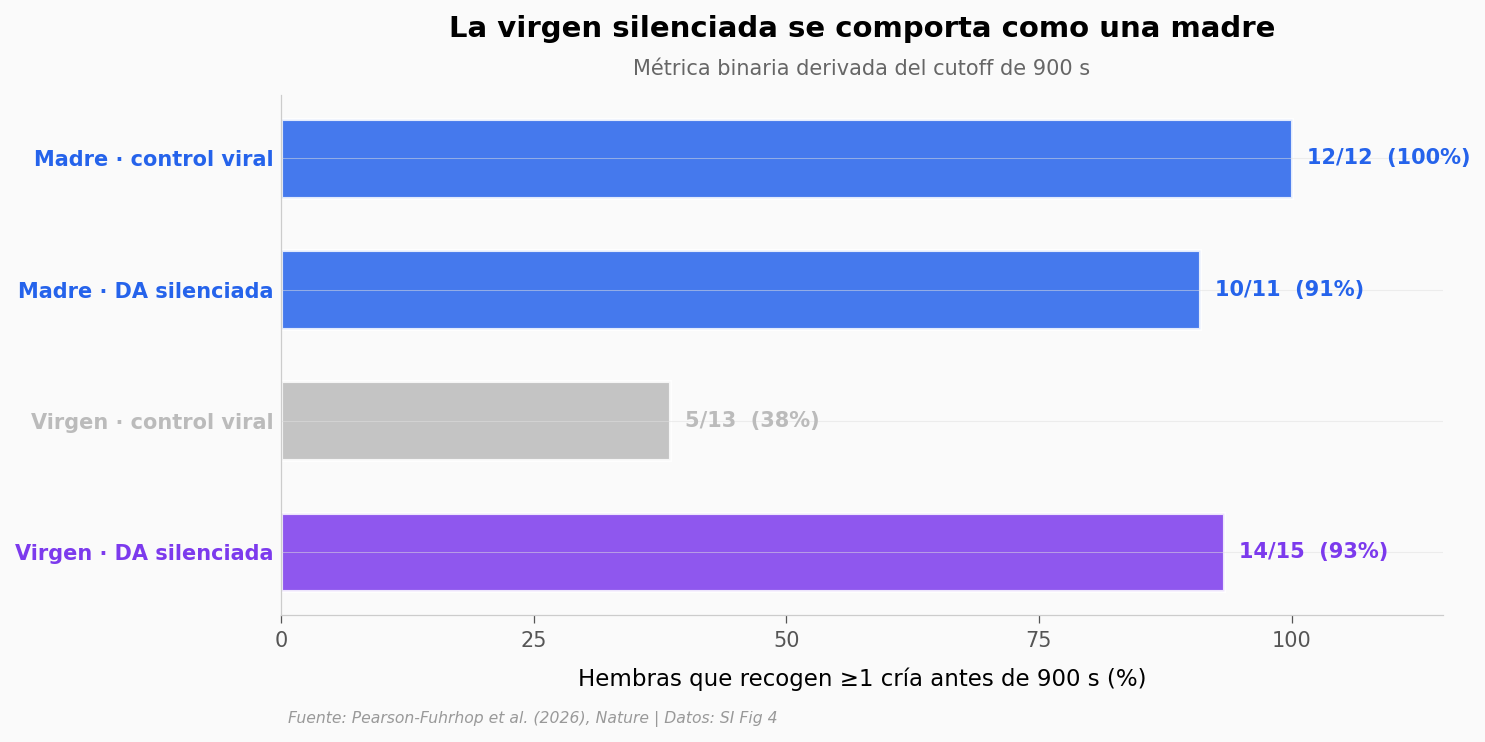

In [4]:
# Tasa de rescate: % de hembras que recogieron al menos una cría antes del cutoff.
# Esto traduce la latencia censurada a una métrica binaria fácil de leer.

resumen = []
for g, v, lbl in combos:
    sub = df_fig4[(df_fig4['grupo']==g) & (df_fig4['virus']==v)]
    n = len(sub)
    rescatan = int((sub['pup1_latencia_s'] < CUTOFF_LATENCIA).sum())
    resumen.append({'combo': lbl, 'n': n, 'rescatan': rescatan, 'pct': 100*rescatan/n})
res = pd.DataFrame(resumen)
print(res.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(range(len(res)), res['pct'].values,
               color=colores4, alpha=0.85, height=0.6, edgecolor='white', linewidth=1.5)

for i, (pct, n, rescatan) in enumerate(zip(res['pct'], res['n'], res['rescatan'])):
    ax.text(pct + 1.5, i, f'{rescatan}/{n}  ({pct:.0f}%)',
            va='center', fontsize=10, fontweight='bold', color=colores4[i])

ax.set_yticks(range(len(res)))
ax.set_yticklabels(res['combo'].values, fontsize=10, fontweight='bold')
for tick, c in zip(ax.get_yticklabels(), colores4):
    tick.set_color(c)
ax.invert_yaxis()
ax.set_xlabel('Hembras que recogen ≥1 cría antes de 900 s (%)', fontsize=11)
ax.set_xlim(0, 115)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_title('La virgen silenciada se comporta como una madre',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.04, 'Métrica binaria derivada del cutoff de 900 s',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.05, FUENTE_FIG4, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_tasa_rescate.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan rara es la madre comparada con sus pares vírgenes?

Para cerrar, una vista de todos los 34 ratones de la Fig 2 juntos.

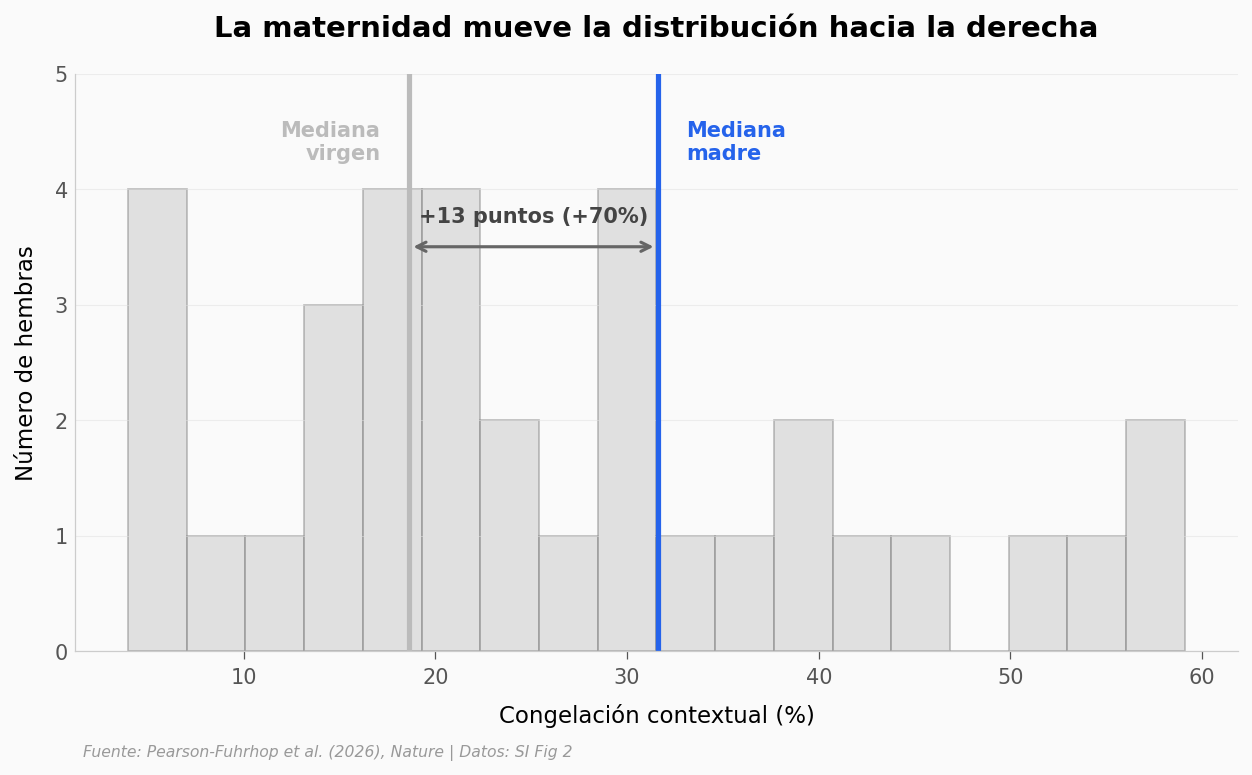


Mediana NP:          18.63%
Mediana Control RE:  31.60%
Diferencia absoluta: 12.97 puntos porcentuales


In [5]:
# Distribución del % de freezing en los 34 ratones, con la mediana de cada grupo.

fig, ax = plt.subplots(figsize=(10, 5))
all_vals = df_fig2['context_test_freezing'].values
n, bins, patches = ax.hist(all_vals, bins=18, color='#CCCCCC', alpha=0.55,
                           edgecolor='#888888', linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Medianas
med_np = df_fig2.loc[df_fig2['grupo']=='NP', 'context_test_freezing'].median()
med_ctrl = df_fig2.loc[df_fig2['grupo']=='Control RE', 'context_test_freezing'].median()

ax.axvline(x=med_np, color=COLOR_NP, linewidth=2.5)
ax.axvline(x=med_ctrl, color=COLOR_CTRL, linewidth=2.5)

# Flecha bidireccional + delta
y_arrow = y_max * 0.7
ax.annotate('', xy=(med_ctrl, y_arrow), xytext=(med_np, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
delta = med_ctrl - med_np
ax.text((med_np + med_ctrl) / 2, y_arrow * 1.06,
        f'+{delta:.0f} puntos (+{100*delta/med_np:.0f}%)',
        ha='center', fontsize=10, fontweight='bold', color='#444444')

# Inline labels
ax.text(med_np - 1.5, y_max * 0.92, 'Mediana\nvirgen', color=COLOR_NP,
        fontsize=10, fontweight='bold', ha='right', va='top')
ax.text(med_ctrl + 1.5, y_max * 0.92, 'Mediana\nmadre', color=COLOR_CTRL,
        fontsize=10, fontweight='bold', ha='left', va='top')

ax.set_xlabel('Congelación contextual (%)', fontsize=11)
ax.set_ylabel('Número de hembras', fontsize=11)
ax.set_title('La maternidad mueve la distribución hacia la derecha',
             fontsize=14, fontweight='bold', pad=18)

fig.text(0.13, -0.03, FUENTE_FIG2, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_distribucion_freezing.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nMediana NP:          {med_np:.2f}%')
print(f'Mediana Control RE:  {med_ctrl:.2f}%')
print(f'Diferencia absoluta: {delta:.2f} puntos porcentuales')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La experiencia reproductiva potencia el aprendizaje contextual | ✅ | Control RE vs NP: mediana 31,6% vs 18,6% · Cohen *d* = 1,22 · Mann-Whitney *p* = 0,021 |
| El estrés postparto crónico reduce esa ventaja | ⚠️ | Stress RE vs Control RE: Cohen *d* = -0,50 · *p* = 0,255 en Mann-Whitney bilateral. El paper lo enmarca como significativo vía ANOVA + post-hoc (mayor potencia); con test simple solo vemos tendencia. Alta varianza individual: algunas madres estresadas sí aprenden. |
| Silenciar dopamina en el dHF de una virgen la lleva a recoger crías | ✅ | NP+hM4Di vs NP+mCherry: Δ mediana -798 s · Cohen *d* = -1,50 · Mann-Whitney *p* = 0,0018 · tasa de rescate 14/15 vs 5/13 |
| El efecto es específico de vírgenes | ✅ | Control RE+hM4Di vs Control RE+mCherry: medianas 24 s vs 15 s — ambas rápidas, sin diferencia conductual relevante |

> **Limitaciones:**
> - Estudio principalmente en ratón (*Mus musculus* C57BL/6J). La validación humana del paper es solo molecular (transcriptoma + H3-dopaminilación en subiculo dorsal postmortem), no conductual.
> - El paradigma de separación maternal-cría modela un estrés postparto crónico extremo — no equivale directamente al estrés postparto humano clínico.
> - El cutoff de 900 s en pup retrieval introduce censura administrativa: subestima la diferencia real, porque varias vírgenes podrían no recoger cría nunca, ni con más tiempo.
> - El mecanismo molecular (H3-dopaminilación como modificación post-traduccional de histonas) está probado en ratón; en humano se infiere por concordancia transcripcional, no por manipulación directa.

## Ahora tú

Tres preguntas que estos datos pueden responder. La celda siguiente es un punto de partida — modifica lo que quieras.

1. **¿Cómo se ve el aprendizaje preshock (días 1-5) antes del test contextual?** Los datos de Fig 2 incluyen `preshock_1` a `preshock_5`. ¿Los tres grupos suben igual durante el condicionamiento, y la diferencia aparece solo en el recall?
2. **¿Importa el ciclo estral (1 vs 2) en la latencia de pup retrieval?** En la Fig 4, la columna `estro` registra la fase de cada hembra. Calcula medianas por estro dentro de cada grupo.
3. **Si excluyes los censurados (latencia = 900 s) del cálculo, ¿qué pasa con la diferencia NP+hM4Di vs Control RE+mCherry?** Esto te da el "mejor caso" — el efecto residual incluso entre las hembras que sí recogen.

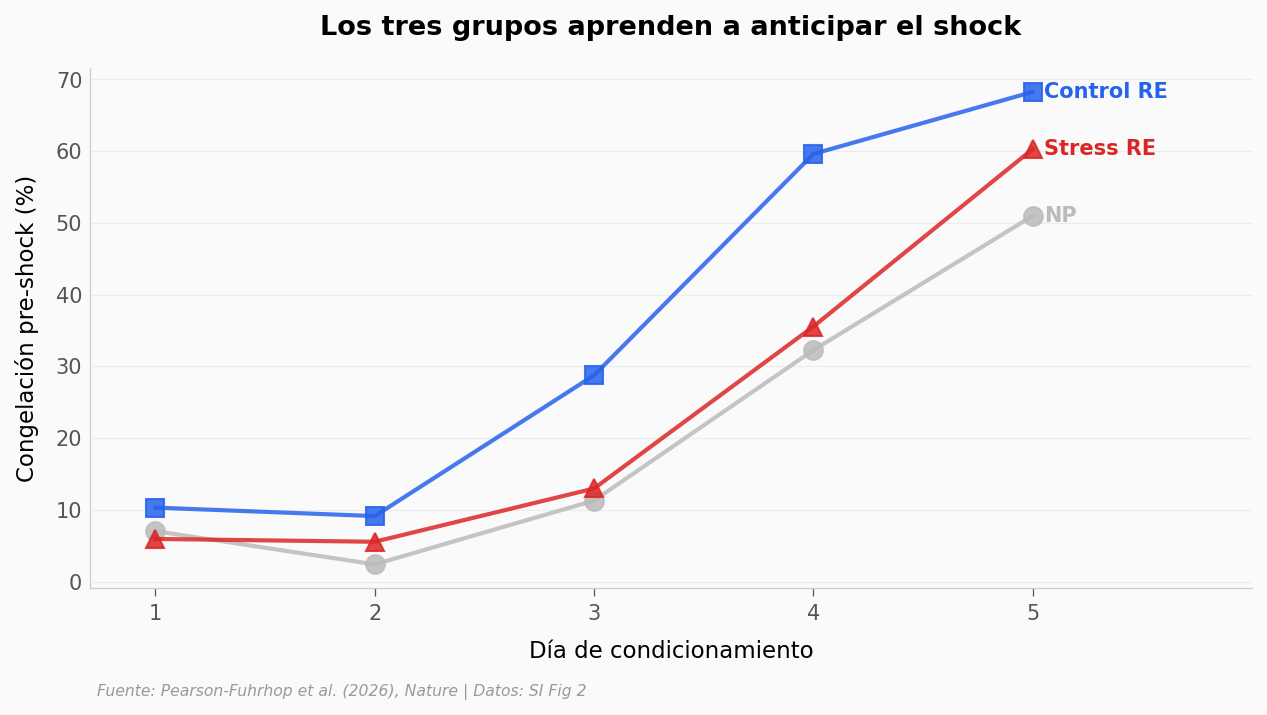

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: curva de aprendizaje preshock por grupo.

preshock_cols = [f'preshock_{i}' for i in range(1, 6)]
curva = df_fig2.groupby('grupo')[preshock_cols].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
estilo = {'NP': (COLOR_NP, 'o'),
          'Control RE': (COLOR_CTRL, 's'),
          'Stress RE': (COLOR_STRESS, '^')}
dias = [1, 2, 3, 4, 5]
for grupo, fila in curva.iterrows():
    col, marker = estilo[grupo]
    ax.plot(dias, fila.values, marker=marker, color=col, linewidth=2, markersize=9,
            label=grupo, alpha=0.85)
    ax.text(5.05, fila.values[-1], grupo, color=col, fontsize=10,
            fontweight='bold', va='center')

ax.set_xticks(dias)
ax.set_xlabel('Día de condicionamiento', fontsize=11)
ax.set_ylabel('Congelación pre-shock (%)', fontsize=11)
ax.set_title('Los tres grupos aprenden a anticipar el shock',
             fontsize=13, fontweight='bold', pad=16)
ax.set_xlim(0.7, 6.0)

fig.text(0.13, -0.05, FUENTE_FIG2, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/05_curva_preshock.png', dpi=200, bbox_inches='tight')
plt.show()

# Inténtalo tú: descomenta para responder la pregunta 3 (excluir censurados)
# no_cens = df_fig4[df_fig4['pup1_latencia_s'] < CUTOFF_LATENCIA]
# print(no_cens.groupby(['grupo', 'virus'])['pup1_latencia_s'].median())

---

## Fuentes

**Paper**: [Dopamine drives persistent remodelling of the maternal brain](https://doi.org/10.1038/s41586-026-10509-4)  
*Nature, 2026-05-14*

**Supplementary Material**: [Source Data Fig 2 & Fig 4 (MOESM5)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10509-4/MediaObjects/41586_2026_10509_MOESM5_ESM.xlsx)  
*Source Data del mismo DOI — CSVs derivados para análisis directo*

*14 afirmaciones del notebook verificadas contra estas fuentes*

**Reproducible:** clona el repo, abre el notebook, ejecuta de arriba a abajo. Los CSVs vienen del Supplementary del propio paper, transcritos a `.csv` para análisis directo. Licencia: CC-BY 4.0 sobre la narrativa y el código; los datos siguen la licencia del paper original.

[github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)